# Econométrie

In [18]:
import geopandas as gpd
import pandas as pd
import os
if os.getcwd().endswith("notebooks"):
    os.chdir('..')

# Load a sample geospatial dataset
gdf = gpd.read_file("cache/results/logements_transport_final.geojson")

# Display the first few rows of the GeoDataFrame
# ensure every column is shown
pd.set_option('display.max_columns', None)
print(gdf.keys())

gdf = gdf.drop(columns=["adresse", "Commune", "Code commune",
                        "nearest_bus_stop_id", "nearest_metro_stop_id",
                        "nearest_train_stop_id", "nearest_tramway_stop_id", 'result_score_next', 'result_label',
                        'result_type', 'result_id', 'result_housenumber', 'result_name',
                        'result_street', 'result_postcode', 'result_city', 'result_context',
                        'result_citycode', 'result_oldcitycode', 'result_oldcity',
                        'result_district', 'result_status'])
save_gdf = gdf.copy()

Index(['adresse', 'Code_postal', 'dist_centre_paris_m', 'Department',
       'Type local', 'Commune', 'Surface reelle bati', 'Surface terrain',
       'Nombre pieces principales', 'Code commune',
       'Valeur foncière au mètre carré', 'result_score_next', 'result_label',
       'result_type', 'result_id', 'result_housenumber', 'result_name',
       'result_street', 'result_postcode', 'result_city', 'result_context',
       'result_citycode', 'result_oldcitycode', 'result_oldcity',
       'result_district', 'result_status', 'nearest_bus_stop_id',
       'nearest_bus_dist_m', 'nearest_metro_stop_id', 'nearest_metro_dist_m',
       'nearest_tramway_stop_id', 'nearest_tramway_dist_m',
       'nearest_train_stop_id', 'nearest_train_dist_m',
       'nb_routes_tramway_1km', 'nb_routes_metro_1km', 'nb_routes_train_1km',
       'nb_routes_bus_1km', 'nb_stations_tramway_1km', 'nb_stations_metro_1km',
       'nb_stations_train_1km', 'nb_stations_bus_1km',
       'passage_journalier_tramway_1km'

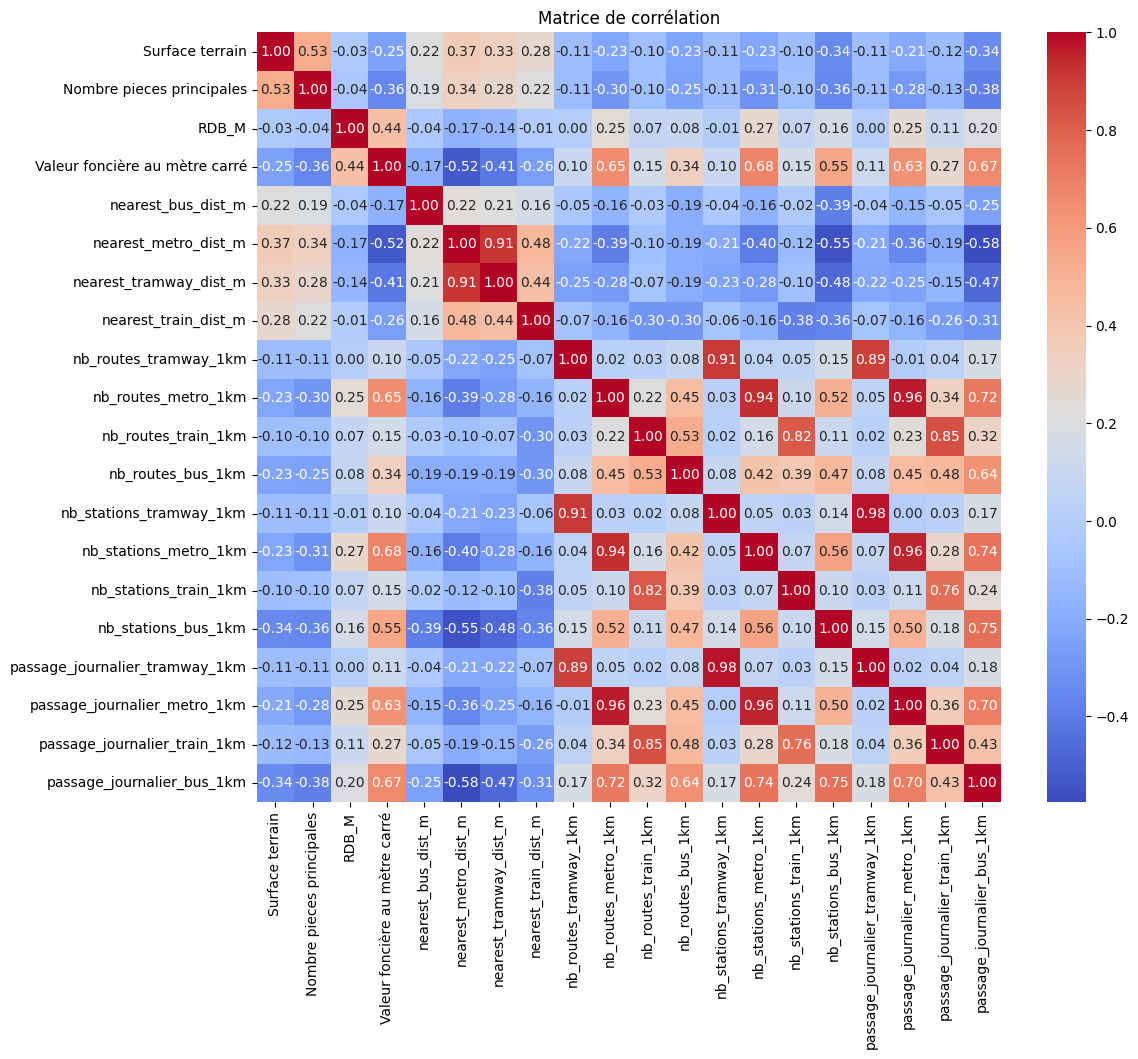

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns 

numerical_vars = [
    'Surface terrain', 'Nombre pieces principales','RDB_M',
    'Valeur foncière au mètre carré', 
    'nearest_bus_dist_m', 'nearest_metro_dist_m', 'nearest_tramway_dist_m', 'nearest_train_dist_m',
    'nb_routes_tramway_1km', 'nb_routes_metro_1km', 'nb_routes_train_1km', 'nb_routes_bus_1km',
    'nb_stations_tramway_1km', 'nb_stations_metro_1km', 'nb_stations_train_1km', 'nb_stations_bus_1km',
    'passage_journalier_tramway_1km', 'passage_journalier_metro_1km',
    'passage_journalier_train_1km', 'passage_journalier_bus_1km'
]

gdf_num = gdf[numerical_vars]

corr_matrix = gdf_num.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

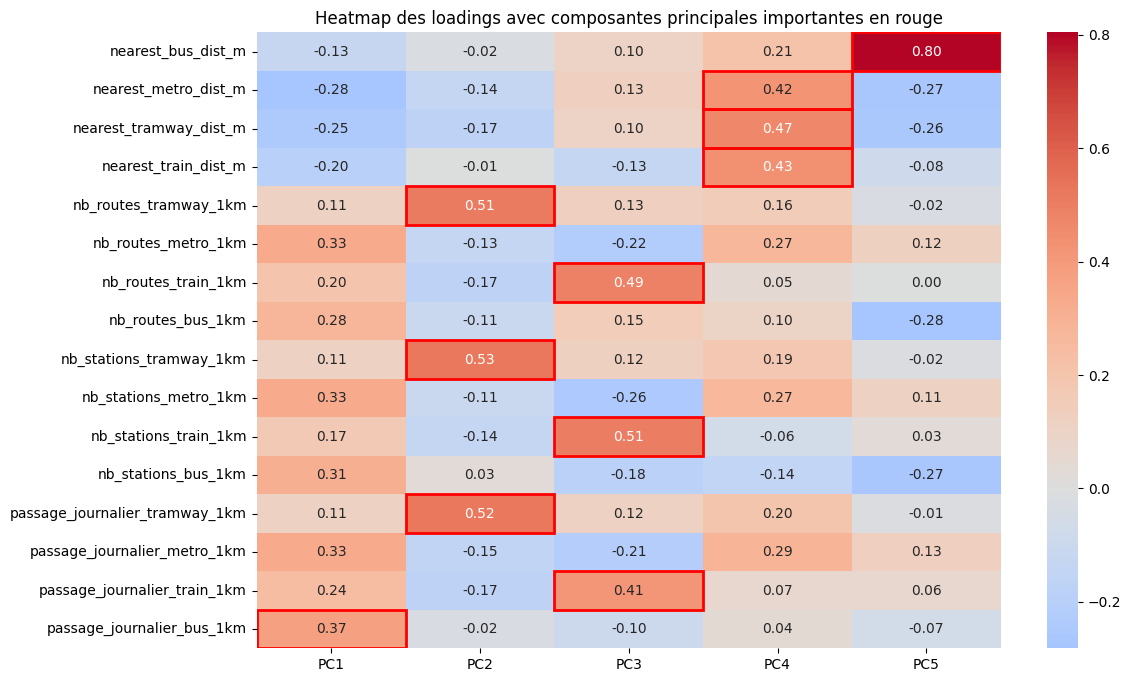

In [20]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Sélection des variables de transport ---
transport_vars = [
    'nearest_bus_dist_m', 'nearest_metro_dist_m', 'nearest_tramway_dist_m', 'nearest_train_dist_m',
    'nb_routes_tramway_1km', 'nb_routes_metro_1km', 'nb_routes_train_1km', 'nb_routes_bus_1km',
    'nb_stations_tramway_1km', 'nb_stations_metro_1km', 'nb_stations_train_1km', 'nb_stations_bus_1km',
    'passage_journalier_tramway_1km', 'passage_journalier_metro_1km',
    'passage_journalier_train_1km', 'passage_journalier_bus_1km'
]

X = gdf[transport_vars]

# --- Standardisation ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- ACP ---
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# --- DataFrame des loadings ---
loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f'PC{i+1}' for i in range(5)], 
                        index=transport_vars)

# --- Heatmap des loadings ---
plt.figure(figsize=(12,8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt=".2f")

# Ajouter un rectangle rouge autour des valeurs "importantes"
threshold = 0.35
for i, col in enumerate(loadings.columns):
    for j, val in enumerate(loadings[col]):
        if abs(val) > threshold:
            plt.gca().add_patch(plt.Rectangle((i, j), 1, 1, fill=False, edgecolor='red', lw=2))

plt.title("Heatmap des loadings avec composantes principales importantes en rouge")
plt.show()


,Composante,Variance expliquée,Variance cumulée
0,PC1,0.358,0.358
1,PC2,0.183,0.540
2,PC3,0.149,0.689
3,PC4,0.102,0.792
4,PC5,0.062,0.853


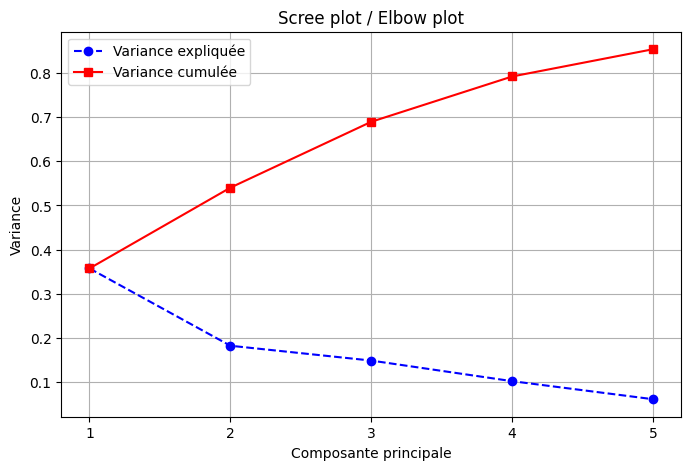

In [21]:
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import pandas as pd

# Variance expliquée et cumulée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

# Création du DataFrame
df_variance = pd.DataFrame({
    'Composante': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Variance expliquée': explained_variance.round(3),
    'Variance cumulée': cumulative_variance.round(3)
})

# Affichage avec titre
display(HTML("<h3>Variance expliquée et cumulée par composante</h3>"))
display(df_variance)

# Scree plot
composantes = range(1, len(explained_variance)+1)

plt.figure(figsize=(8,5))
plt.plot(composantes, explained_variance, marker='o', linestyle='--', color='b', label='Variance expliquée')
plt.plot(composantes, [sum(explained_variance[:i]) for i in composantes], marker='s', linestyle='-', color='r', label='Variance cumulée')
plt.xlabel('Composante principale')
plt.ylabel('Variance')
plt.title('Scree plot / Elbow plot')
plt.xticks(composantes)
plt.grid(True)
plt.legend()
plt.show()


In [22]:

valeurs_propres = pca.explained_variance_

# Création du DataFrame
df_valeurs_propres = pd.DataFrame({
    'Composante': [f'PC{i+1}' for i in range(len(valeurs_propres))],
    'Valeur propre': valeurs_propres
})

# Formater les valeurs propres avec 2 décimales pour plus de lisibilité
df_valeurs_propres['Valeur propre'] = df_valeurs_propres['Valeur propre'].apply(lambda x: round(x, 2))

# Affichage avec un titre et bordures pour plus de lisibilité (si tu utilises Jupyter Notebook)
from IPython.display import display, HTML
print("=== Valeurs propres des composantes principales (critère de Kaiser) ===")
display(HTML(df_valeurs_propres.to_html(index=False)))



=== Valeurs propres des composantes principales (critère de Kaiser) ===


Composante,Valeur propre
PC1,5.72
PC2,2.92
PC3,2.39
PC4,1.64
PC5,0.99


In [23]:

# On ne garde que les 5 premières
for i in range(5):
    gdf[f'PC{i+1}_transport'] = X_pca[:, i]

# Liste des colonnes PCA existantes ou variables de transport à supprimer
transport_vars = [
    'nearest_bus_dist_m', 'nearest_metro_dist_m', 'nearest_tramway_dist_m', 'nearest_train_dist_m',
    'nb_routes_tramway_1km', 'nb_routes_metro_1km', 'nb_routes_train_1km', 'nb_routes_bus_1km',
    'nb_stations_tramway_1km', 'nb_stations_metro_1km', 'nb_stations_train_1km', 'nb_stations_bus_1km',
    'passage_journalier_tramway_1km', 'passage_journalier_metro_1km',
    'passage_journalier_train_1km', 'passage_journalier_bus_1km'
]

# Supprimer les colonnes de transport et les anciennes colonnes PCA si elles existent
cols_to_drop = transport_vars + [f'PC{i}_transport' for i in range(6, gdf.shape[1])]
gdf = gdf.drop(columns=[c for c in cols_to_drop if c in gdf.columns])

# Vérifier le résultat
gdf.head()


,Code_postal,dist_centre_paris_m,Department,Type local,Surface reelle bati,Surface terrain,Nombre pieces principales,Valeur foncière au mètre carré,RDB_M,geometry,PC1_transport,PC2_transport,PC3_transport,PC4_transport,PC5_transport
0,93250,18495.327994,93,Appartement,37.0,0.0,2.0,4135.135135,22880.0,POINT (2.50639 48.89254),0.998415,4.280341,2.337171,0.028273,-0.151382
1,77370,91147.159895,77,Maison,81.0,232.0,4.0,2888.888889,18930.0,POINT (3.02135 48.55532),-2.825286,-1.133420,0.628289,2.070938,-1.744351
2,78260,35301.849789,78,Maison,88.0,408.0,4.0,3784.090909,21970.0,POINT (2.06194 48.9531),-1.078750,-0.091152,-0.596341,-0.461426,-0.388912
3,92140,11748.500396,92,Maison,95.0,0.0,4.0,7476.315789,27580.0,POINT (2.27316 48.8121),0.472185,-0.538375,1.333417,-1.534311,0.100886
4,93290,29249.801463,93,Appartement,63.0,0.0,4.0,2523.809524,20710.0,POINT (2.57231 48.95058),-1.121060,-0.058966,-0.356036,-0.976224,-0.330702


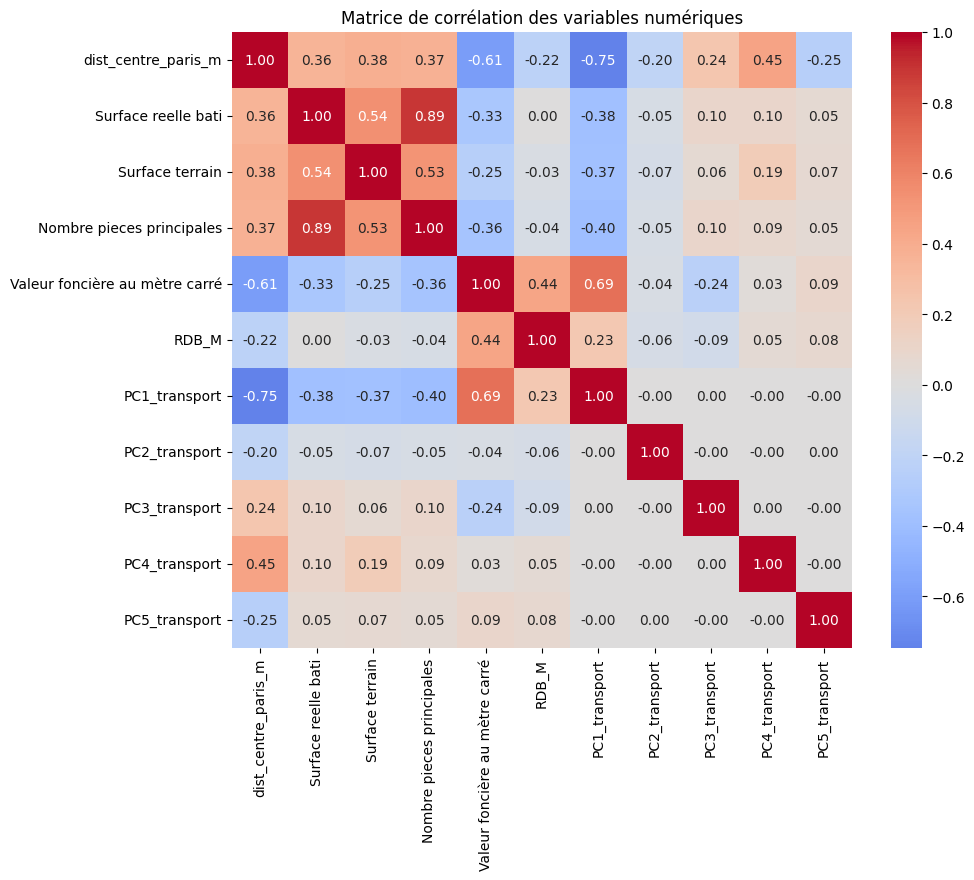

In [24]:

gdf_numeric = gdf.select_dtypes(include='number')
corr_matrix = gdf_numeric.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

In [25]:
print("Nombre de NaN par colonne :")
print(gdf_numeric.isna().sum())

Nombre de NaN par colonne :
dist_centre_paris_m                 0
Surface reelle bati               190
Surface terrain                    38
Nombre pieces principales         190
Valeur foncière au mètre carré      0
RDB_M                              93
PC1_transport                       0
PC2_transport                       0
PC3_transport                       0
PC4_transport                       0
PC5_transport                       0
dtype: int64


In [26]:
from sklearn.linear_model import LassoCV

gdf_clean = gdf_numeric.dropna()

# Variables explicatives et cible
X = gdf_clean.drop(columns=['Valeur foncière au mètre carré'])  
y = gdf_clean['Valeur foncière au mètre carré']

# Standardisation (très important pour Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Lasso avec validation croisée pour trouver alpha optimal
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, y)

# Coefficients
coef = pd.Series(lasso.coef_, index=X.columns)
print("Coefficients Lasso :")
print(coef.sort_values(ascending=False))

# Variables retenues (coef != 0)
selected_vars = coef[coef != 0].index.tolist()
print("\nVariables sélectionnées par Lasso :")
print(selected_vars)

Coefficients Lasso :
PC1_transport                1175.930406
RDB_M                         846.796450
PC4_transport                 515.981027
Surface terrain               144.786482
PC5_transport                 -10.962066
Surface reelle bati          -169.762458
Nombre pieces principales    -211.904536
PC2_transport                -296.668036
PC3_transport                -420.800441
dist_centre_paris_m         -1034.732943
dtype: float64

Variables sélectionnées par Lasso :
['dist_centre_paris_m', 'Surface reelle bati', 'Surface terrain', 'Nombre pieces principales', 'RDB_M', 'PC1_transport', 'PC2_transport', 'PC3_transport', 'PC4_transport', 'PC5_transport']


In [28]:
import statsmodels.api as sm

X_selected = gdf_clean[['dist_centre_paris_m', 'Surface reelle bati', 'Surface terrain', 'Nombre pieces principales', 'RDB_M', 'PC1_transport', 'PC2_transport', 'PC3_transport', 'PC4_transport', 'PC5_transport']]
y = gdf_clean['Valeur foncière au mètre carré']

# Ajouter une constante
X_selected = sm.add_constant(X_selected)

# Modèle OLS
model = sm.OLS(y, X_selected).fit()

# Résumé du modèle
print(model.summary())


                                  OLS Regression Results                                  
Dep. Variable:     Valeur foncière au mètre carré   R-squared:                       0.625
Model:                                        OLS   Adj. R-squared:                  0.625
Method:                             Least Squares   F-statistic:                 1.203e+04
Date:                            Mon, 29 Dec 2025   Prob (F-statistic):               0.00
Time:                                    15:56:03   Log-Likelihood:            -6.5168e+05
No. Observations:                           72277   AIC:                         1.303e+06
Df Residuals:                               72266   BIC:                         1.303e+06
Df Model:                                      10                                         
Covariance Type:                        nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.9